# Fix Data Leakage: Repartition at Original ID Level

In [11]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)

In [13]:
import os
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

ROOT = Path('/kaggle/input/datasets/karagwaanntreasure/plant-disease-detection')
DATASET_ROOT = ROOT / 'Dataset'
OUTPUT_DIR = Path("/kaggle/working/")
SPLIT_ROOT = OUTPUT_DIR / Path('Dataset_Split')
MODELS_DIR = OUTPUT_DIR / 'models' / 'mobilenetv2'
SEED = 42

np.random.seed(SEED)

## Extract Original IDs & Group Augmentations

In [3]:
class_folders = sorted([d for d in DATASET_ROOT.iterdir() if d.is_dir()])

id_to_images = defaultdict(lambda: defaultdict(list))

for class_dir in class_folders:
    class_name = class_dir.name
    images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg')) + list(class_dir.glob('*.JPG'))
    
    for img_path in images:
        filename = img_path.name
        original_id = filename.split('___')[0]
        id_to_images[original_id][class_name].append(img_path)

total_ids = len(id_to_images)
print(f"Total unique original IDs: {total_ids}")
print(f"Total images: {sum(len(imgs) for class_dict in id_to_images.values() for imgs in class_dict.values())}")

sample_id = list(id_to_images.keys())[0]
print(f"\nSample ID {sample_id}:")
for cls, paths in id_to_images[sample_id].items():
    print(f"  {cls}: {len(paths)} augmentations")

Total unique original IDs: 28077
Total images: 35725

Sample ID c4e2b47d-d3c9-418e-9e60-78cead67c5d7:
  Apple___Apple_scab: 4 augmentations


## Split IDs into Train/Val/Test

In [4]:
all_ids = np.array(list(id_to_images.keys()))
np.random.shuffle(all_ids)

n_train = int(len(all_ids) * 0.8)
n_val = int(len(all_ids) * 0.1)

train_ids = set(all_ids[:n_train])
val_ids = set(all_ids[n_train:n_train + n_val])
test_ids = set(all_ids[n_train + n_val:])

print(f"Train IDs: {len(train_ids)}")
print(f"Val IDs: {len(val_ids)}")
print(f"Test IDs: {len(test_ids)}")
print(f"\nVerify no overlap: {len(train_ids & val_ids & test_ids) == 0}")

Train IDs: 22461
Val IDs: 2807
Test IDs: 2809

Verify no overlap: True


## Create Split Directories & Copy Files

In [5]:
for split in ['train', 'val', 'test']:
    split_dir = SPLIT_ROOT / split
    split_dir.mkdir(parents=True, exist_ok=True)

    for class_dir in class_folders:
        class_split_dir = split_dir / class_dir.name
        class_split_dir.mkdir(parents=True, exist_ok=True)

print(f"Created directory structure at {SPLIT_ROOT}")

Created directory structure at /kaggle/working/Dataset_Split


## Assign Images to Splits

In [6]:
split_counts = {'train': 0, 'val': 0, 'test': 0}

for original_id, class_dict in id_to_images.items():
    if original_id in train_ids:
        split = 'train'
    elif original_id in val_ids:
        split = 'val'
    else:
        split = 'test'

    for class_name, img_paths in class_dict.items():
        dst_dir = SPLIT_ROOT / split / class_name
        for img_path in img_paths:
            dst_path = dst_dir / img_path.name
            shutil.copy2(img_path, dst_path)
            split_counts[split] += 1

print("\nImages copied to splits:")
for split, count in split_counts.items():
    pct = (count / sum(split_counts.values())) * 100
    print(f"  {split}: {count} ({pct:.1f}%)")


Images copied to splits:
  train: 28657 (80.2%)
  val: 3536 (9.9%)
  test: 3532 (9.9%)


## Verify Split Class Distributions

In [7]:
split_class_counts = {}

for split in ['train', 'val', 'test']:
    split_class_counts[split] = {}
    split_dir = SPLIT_ROOT / split

    for class_dir in (split_dir).iterdir():
        if class_dir.is_dir():
            images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg')) + list(class_dir.glob('*.JPG'))
            split_class_counts[split][class_dir.name] = len(images)

print("\nClass distribution per split:")
for split in ['train', 'val', 'test']:
    total = sum(split_class_counts[split].values())
    print(f"\n{split.upper()} ({total} images):")
    for cls, count in sorted(split_class_counts[split].items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {cls}: {count}")


Class distribution per split:

TRAIN (28657 images):
  Tomato__Tomato_YellowLeaf__Curl_Virus: 2529
  Tomato_Bacterial_spot: 1699
  Apple___Apple_scab: 1632
  Apple___healthy: 1602
  Apple___Black_rot: 1574

VAL (3536 images):
  Tomato__Tomato_YellowLeaf__Curl_Virus: 343
  Apple___Black_rot: 219
  Tomato_Bacterial_spot: 208
  Apple___Apple_scab: 201
  Tomato_Late_blight: 198

TEST (3532 images):
  Tomato__Tomato_YellowLeaf__Curl_Virus: 336
  Tomato_Bacterial_spot: 220
  Apple___healthy: 211
  Corn_(maize)___healthy: 207
  Apple___Black_rot: 194


## Leakage Verification

In [8]:
def extract_original_ids(split_dir):
    ids = set()
    for class_dir in split_dir.iterdir():
        if class_dir.is_dir():
            for img_path in class_dir.glob('*'):
                if img_path.is_file():
                    original_id = img_path.name.split('___')[0]
                    ids.add(original_id)
    return ids

train_ids_check = extract_original_ids(SPLIT_ROOT / 'train')
val_ids_check = extract_original_ids(SPLIT_ROOT / 'val')
test_ids_check = extract_original_ids(SPLIT_ROOT / 'test')

train_val_overlap = len(train_ids_check & val_ids_check)
train_test_overlap = len(train_ids_check & test_ids_check)
val_test_overlap = len(val_ids_check & test_ids_check)

print("\nLEAKAGE VERIFICATION:")
print(f"Train-Val overlap: {train_val_overlap}")
print(f"Train-Test overlap: {train_test_overlap}")
print(f"Val-Test overlap: {val_test_overlap}")
print(f"\nResult: {'✓ ZERO LEAKAGE' if (train_val_overlap + train_test_overlap + val_test_overlap) == 0 else '✗ LEAKAGE DETECTED'}")


LEAKAGE VERIFICATION:
Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0

Result: ✓ ZERO LEAKAGE


## Generate Split Summary CSV

In [9]:
summary_data = []

for split in ['train', 'val', 'test']:
    for cls, count in split_class_counts[split].items():
        summary_data.append({
            'Split': split,
            'Class': cls,
            'Count': count
        })

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(SPLIT_ROOT / 'split_summary.csv', index=False)

print("Summary saved to split_summary.csv")
print(f"\nTotal images in split: {len(summary_df) // 3} classes × 3 splits")

Summary saved to split_summary.csv

Total images in split: 23 classes × 3 splits


## Final Report

In [10]:
train_total = sum(split_class_counts['train'].values())
val_total = sum(split_class_counts['val'].values())
test_total = sum(split_class_counts['test'].values())
grand_total = train_total + val_total + test_total

print("\n" + "="*60)
print("DATA REPARTITIONING COMPLETE")
print("="*60)
print(f"\nTotal images: {grand_total}")
print(f"  Train: {train_total} ({train_total/grand_total*100:.1f}%)")
print(f"  Val: {val_total} ({val_total/grand_total*100:.1f}%)")
print(f"  Test: {test_total} ({test_total/grand_total*100:.1f}%)")
print(f"\nTotal classes: {len(split_class_counts['train'])}")
print(f"Original image IDs used: {len(train_ids | val_ids | test_ids)}")
print(f"\nLeakage status: {'✓ ZERO LEAKAGE' if (train_val_overlap + train_test_overlap + val_test_overlap) == 0 else '✗ LEAKAGE DETECTED'}")
print(f"\nOutput directory: {SPLIT_ROOT}")


DATA REPARTITIONING COMPLETE

Total images: 35725
  Train: 28657 (80.2%)
  Val: 3536 (9.9%)
  Test: 3532 (9.9%)

Total classes: 23
Original image IDs used: 28077

Leakage status: ✓ ZERO LEAKAGE

Output directory: /kaggle/working/Dataset_Split


In [14]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
EPOCHS = 30
SAVE_EVERY = 5
SUBSET_PERCENTAGE = 50
MODELS_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Models will be saved to: {MODELS_DIR}")
print(f"Save checkpoint every {SAVE_EVERY} epochs")
print(f"Using {SUBSET_PERCENTAGE}% of dataset")

Models will be saved to: /kaggle/working/models/mobilenetv2
Save checkpoint every 5 epochs
Using 50% of dataset


In [15]:
class SaveEveryNEpochs(tf.keras.callbacks.Callback):
    def __init__(self, save_every, save_dir, model_name):
        super().__init__()
        self.save_every = save_every
        self.save_dir = Path(save_dir)
        self.model_name = model_name
        self.best_val_acc = 0.0

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.save_every == 0:
            path = self.save_dir / f'{self.model_name}_epoch_{epoch + 1:02d}.keras'
            self.model.save(str(path))
            print(f"Saved checkpoint: {path.name}")

        if logs and logs.get('val_accuracy', 0) > self.best_val_acc:
            self.best_val_acc = logs['val_accuracy']
            path = self.save_dir / f'{self.model_name}_best_epoch_{epoch + 1:02d}.keras'
            self.model.save(str(path))
            print(f"Saved best model: {path.name} (val_acc={self.best_val_acc:.4f})")

In [23]:
with open('/kaggle/input/models/anshlulla/class-weights-pkl/other/default/1/class_weights.pkl', 'rb') as f:
    class_weights = pickle.load(f)

class_names = [
  "Apple___Apple_scab",
  "Apple___Black_rot",
  "Apple___Cedar_apple_rust",
  "Apple___healthy",
  "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
  "Corn_(maize)___Common_rust_",
  "Corn_(maize)___Northern_Leaf_Blight",
  "Corn_(maize)___healthy",
  "Pepper__bell___Bacterial_spot",
  "Pepper__bell___healthy",
  "Potato___Early_blight",
  "Potato___Late_blight",
  "Potato___healthy",
  "Tomato_Bacterial_spot",
  "Tomato_Early_blight",
  "Tomato_Late_blight",
  "Tomato_Leaf_Mold",
  "Tomato_Septoria_leaf_spot",
  "Tomato_Spider_mites_Two_spotted_spider_mite",
  "Tomato__Target_Spot",
  "Tomato__Tomato_YellowLeaf__Curl_Virus",
  "Tomato__Tomato_mosaic_virus",
  "Tomato_healthy"
]

NUM_CLASSES = len(class_names)

In [33]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal', seed=SEED),
    tf.keras.layers.RandomRotation(0.1, seed=SEED),
])

def load_dataset(split='train', augment=False, subset_percent=None):
    if subset_percent is None:
        subset_percent = SUBSET_PERCENTAGE

    split_dir = SPLIT_ROOT / split

    ds = tf.keras.utils.image_dataset_from_directory(
        split_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        class_names=class_names,
        seed=SEED,
        shuffle=(split == 'train')
    )

    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE)

    if augment and split == 'train':
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    if subset_percent < 100:
        # Unbatch to ensure all classes represented
        unbatched = ds.unbatch()

        image_extensions = {
            '.jpg', '.jpeg', '.png',
            '.JPG', '.JPEG', '.PNG'
        }
        
        total_samples = sum(
            1
            for class_dir in split_dir.iterdir()
            if class_dir.is_dir()
            for file in class_dir.iterdir()
            if file.is_file() and file.suffix.lower() in {
                '.jpg', '.jpeg', '.png'
            }
        )
        # Count total samples
        samples_to_take = max(NUM_CLASSES, int(total_samples * subset_percent / 100))
        unbatched = unbatched.shuffle(buffer_size=10000, seed=SEED).take(samples_to_take)
        ds = unbatched.batch(BATCH_SIZE)
        print(f'{split}: Taking ~{samples_to_take} images ({subset_percent}%)')

    ds = ds.cache().prefetch(tf.data.AUTOTUNE)
    return ds

def load_dataset_efficientnet(split='train', augment=False, subset_percent=None):
    if subset_percent is None:
        subset_percent = SUBSET_PERCENTAGE

    split_dir = SPLIT_ROOT / split

    ds = tf.keras.utils.image_dataset_from_directory(
        split_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        class_names=class_names,
        seed=SEED,
        shuffle=(split == 'train')
    )

    # EfficientNetB0 preprocessing on [0,255]
    from tensorflow.keras.applications.efficientnet import preprocess_input
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)

    if augment and split == 'train':
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    if subset_percent < 100:
        # Unbatch to ensure all classes represented
        unbatched = ds.unbatch()
        # Count total samples
        image_extensions = {
            '.jpg', '.jpeg', '.png',
            '.JPG', '.JPEG', '.PNG'
        }
        
        total_samples = sum(
            1
            for class_dir in split_dir.iterdir()
            if class_dir.is_dir()
            for file in class_dir.iterdir()
            if file.is_file() and file.suffix.lower() in {
                '.jpg', '.jpeg', '.png'
            }
        )
        samples_to_take = max(NUM_CLASSES, int(total_samples * subset_percent / 100))
        unbatched = unbatched.shuffle(buffer_size=10000, seed=SEED).take(samples_to_take)
        ds = unbatched.batch(BATCH_SIZE)

    ds = ds.cache().prefetch(tf.data.AUTOTUNE)
    return ds

In [24]:
def build_mobilenetv2():
    base = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
    base.trainable = False

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.7)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return models.Model(inputs, outputs)

mobilenetv2_model = build_mobilenetv2()
mobilenetv2_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("MobileNetV2 model built and compiled")

MobileNetV2 model built and compiled


In [29]:
train_ds = load_dataset('train', augment=True, subset_percent=SUBSET_PERCENTAGE)
val_ds = load_dataset('val', augment=False, subset_percent=SUBSET_PERCENTAGE)
test_ds = load_dataset('test', augment=False, subset_percent=SUBSET_PERCENTAGE)

print("Datasets loaded")

Found 28657 files belonging to 23 classes.
train: Taking ~14328 images (50%)
Found 3536 files belonging to 23 classes.
val: Taking ~1768 images (50%)
Found 3532 files belonging to 23 classes.
test: Taking ~1766 images (50%)
Datasets loaded


In [30]:
mobilenetv2_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'mobilenetv2_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    SaveEveryNEpochs(save_every=SAVE_EVERY, save_dir=MODELS_DIR, model_name='mobilenetv2')
]

print("Training MobileNetV2...\n")
mobilenetv2_history = mobilenetv2_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=mobilenetv2_callbacks,
    verbose=1
)

Training MobileNetV2...

Epoch 1/30


2026-08-23 16:10:17.633534: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:10:17.770297: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1787501420.222059     220 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    895/Unknown 89s 47ms/step - accuracy: 0.5222 - loss: 2.0096

2026-08-23 16:11:11.207915: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:11:11.361983: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:11:11.497575: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


    896/Unknown 101s 60ms/step - accuracy: 0.5223 - loss: 2.0090Saved best model: mobilenetv2_best_epoch_01.keras (val_acc=0.8790)
896/896 ━━━━━━━━━━━━━━━━━━━━ 114s 75ms/step - accuracy: 0.6342 - loss: 1.4362 - val_accuracy: 0.8790 - val_loss: 0.3713 - learning_rate: 0.0010
Epoch 2/30
896/896 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7567 - loss: 0.8686Saved best model: mobilenetv2_best_epoch_02.keras (val_acc=0.9055)
896/896 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.7693 - loss: 0.7979 - val_accuracy: 0.9055 - val_loss: 0.3155 - learning_rate: 0.0010
Epoch 3/30
896/896 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.8007 - loss: 0.6523 - val_accuracy: 0.9038 - val_loss: 0.2887 - learning_rate: 0.0010
Epoch 4/30
895/896 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8197 - loss: 0.5797Saved best model: mobilenetv2_best_epoch_04.keras (val_acc=0.9186)
896/896 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.8216 - loss: 0.5675 - val_accuracy: 0.9186 - val_loss: 0.2505 - l

In [34]:
train_ds_eff = load_dataset_efficientnet('train', augment=True, subset_percent=SUBSET_PERCENTAGE)
val_ds_eff = load_dataset_efficientnet('val', augment=False, subset_percent=SUBSET_PERCENTAGE)
test_ds_eff = load_dataset_efficientnet('test', augment=False, subset_percent=SUBSET_PERCENTAGE)

Found 28657 files belonging to 23 classes.
Found 3536 files belonging to 23 classes.
Found 3532 files belonging to 23 classes.


In [35]:
def build_efficientnetb0():
    base = EfficientNetB0(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
    base.trainable = False

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return models.Model(inputs, outputs)

efficientnetb0_model = build_efficientnetb0()
efficientnetb0_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("EfficientNetB0 model built and compiled")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 model built and compiled


In [36]:
p1_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'efficientnetb0_phase1.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    SaveEveryNEpochs(save_every=SAVE_EVERY, save_dir=MODELS_DIR, model_name='efficientnetb0_phase1')
]

print("Phase 1: Training frozen base (15 epochs)...\n")
efficientnetb0_history_p1 = efficientnetb0_model.fit(
    train_ds_eff,
    validation_data=val_ds_eff,
    epochs=15,
    class_weight=class_weights,
    callbacks=p1_callbacks,
    verbose=1
)

Phase 1: Training frozen base (15 epochs)...

Epoch 1/15


2026-08-23 16:26:33.223064: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:26:33.363075: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:26:33.687365: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:26:33.828846: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:26:34.625385: E external/local_xla/xla/stream_

    894/Unknown 95s 49ms/step - accuracy: 0.4165 - loss: 2.1042

2026-08-23 16:27:31.112827: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:27:31.249155: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:27:31.558703: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:27:31.698701: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:27:32.493474: E external/local_xla/xla/stream_

    896/Unknown 109s 65ms/step - accuracy: 0.4168 - loss: 2.1027Saved best model: efficientnetb0_phase1_best_epoch_01.keras (val_acc=0.8597)
896/896 ━━━━━━━━━━━━━━━━━━━━ 127s 86ms/step - accuracy: 0.5921 - loss: 1.4181 - val_accuracy: 0.8597 - val_loss: 0.4846 - learning_rate: 1.0000e-04
Epoch 2/15
896/896 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8018 - loss: 0.6441Saved best model: efficientnetb0_phase1_best_epoch_02.keras (val_acc=0.9078)
896/896 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.8170 - loss: 0.5933 - val_accuracy: 0.9078 - val_loss: 0.3030 - learning_rate: 1.0000e-04
Epoch 3/15
895/896 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8657 - loss: 0.4247Saved best model: efficientnetb0_phase1_best_epoch_03.keras (val_acc=0.9174)
896/896 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.8670 - loss: 0.4179 - val_accuracy: 0.9174 - val_loss: 0.2440 - learning_rate: 1.0000e-04
Epoch 4/15
895/896 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8960 - loss: 0.3250Saved

In [37]:
base_model = efficientnetb0_model.get_layer('efficientnetb0')
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

efficientnetb0_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Base model unfrozen (last 20 layers trainable)")

Base model unfrozen (last 20 layers trainable)


In [38]:
p2_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'efficientnetb0_finetuned.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1),
    SaveEveryNEpochs(save_every=SAVE_EVERY, save_dir=MODELS_DIR, model_name='efficientnetb0_phase2')
]

print("Phase 2: Fine-tuning (30 epochs)...\n")
efficientnetb0_history_p2 = efficientnetb0_model.fit(
    train_ds_eff,
    validation_data=val_ds_eff,
    epochs=30,
    class_weight=class_weights,
    callbacks=p2_callbacks,
    verbose=1
)

print(f"\nModels saved to {MODELS_DIR}")

Phase 2: Fine-tuning (30 epochs)...

Epoch 1/30
    896/Unknown 60s 38ms/step - accuracy: 0.8535 - loss: 0.4696Saved best model: efficientnetb0_phase2_best_epoch_01.keras (val_acc=0.9316)
896/896 ━━━━━━━━━━━━━━━━━━━━ 75s 55ms/step - accuracy: 0.8705 - loss: 0.4025 - val_accuracy: 0.9316 - val_loss: 0.2007 - learning_rate: 1.0000e-05
Epoch 2/30
894/896 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9034 - loss: 0.2760Saved best model: efficientnetb0_phase2_best_epoch_02.keras (val_acc=0.9434)
896/896 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.9103 - loss: 0.2634 - val_accuracy: 0.9434 - val_loss: 0.1722 - learning_rate: 1.0000e-05
Epoch 3/30
894/896 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9257 - loss: 0.2144Saved best model: efficientnetb0_phase2_best_epoch_03.keras (val_acc=0.9463)
896/896 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.9288 - loss: 0.2035 - val_accuracy: 0.9463 - val_loss: 0.1567 - learning_rate: 1.0000e-05
Epoch 4/30
895/896 ━━━━━━━━━━━━━━━━━━━━ 0s 23

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import numpy as np

# Load best models
mobilenetv2_best = tf.keras.models.load_model(str(MODELS_DIR / 'mobilenetv2_best.keras'))
efficientnetb0_best = tf.keras.models.load_model(str(MODELS_DIR / 'efficientnetb0_finetuned.keras'))

print("Best models loaded\n")

# MobileNetV2 evaluation
print("="*60)
print("MobileNetV2 - TEST SET RESULTS")
print("="*60)
mobilenetv2_test_loss, mobilenetv2_test_acc = mobilenetv2_best.evaluate(test_ds, verbose=0)
print(f"Accuracy: {mobilenetv2_test_acc:.4f}")
print(f"Loss: {mobilenetv2_test_loss:.4f}")

# Get predictions for precision, recall, F1
mobilenetv2_preds = mobilenetv2_best.predict(test_ds, verbose=0)
mobilenetv2_pred_classes = np.argmax(mobilenetv2_preds, axis=1)

# Collect true labels from test_ds
mobilenetv2_true_labels = []
for _, labels in test_ds:
    mobilenetv2_true_labels.extend(np.argmax(labels.numpy(), axis=1))
mobilenetv2_true_labels = np.array(mobilenetv2_true_labels)

print("\nPrecision (macro): {:.4f}".format(precision_score(mobilenetv2_true_labels, mobilenetv2_pred_classes, average='macro', zero_division=0)))
print("Recall (macro): {:.4f}".format(recall_score(mobilenetv2_true_labels, mobilenetv2_pred_classes, average='macro', zero_division=0)))
print("F1 (macro): {:.4f}".format(f1_score(mobilenetv2_true_labels, mobilenetv2_pred_classes, average='macro', zero_division=0)))

print("\nPer-class metrics:")
print(classification_report(mobilenetv2_true_labels, mobilenetv2_pred_classes, target_names=class_names, zero_division=0))

# EfficientNetB0 evaluation
print("\n" + "="*60)
print("EfficientNetB0 - TEST SET RESULTS")
print("="*60)
efficientnetb0_test_loss, efficientnetb0_test_acc = efficientnetb0_best.evaluate(test_ds_eff, verbose=0)
print(f"Accuracy: {efficientnetb0_test_acc:.4f}")
print(f"Loss: {efficientnetb0_test_loss:.4f}")

# Get predictions
efficientnetb0_preds = efficientnetb0_best.predict(test_ds_eff, verbose=0)
efficientnetb0_pred_classes = np.argmax(efficientnetb0_preds, axis=1)

# Collect true labels
efficientnetb0_true_labels = []
for _, labels in test_ds_eff:
    efficientnetb0_true_labels.extend(np.argmax(labels.numpy(), axis=1))
efficientnetb0_true_labels = np.array(efficientnetb0_true_labels)

print("\nPrecision (macro): {:.4f}".format(precision_score(efficientnetb0_true_labels, efficientnetb0_pred_classes, average='macro', zero_division=0)))
print("Recall (macro): {:.4f}".format(recall_score(efficientnetb0_true_labels, efficientnetb0_pred_classes, average='macro', zero_division=0)))
print("F1 (macro): {:.4f}".format(f1_score(efficientnetb0_true_labels, efficientnetb0_pred_classes, average='macro', zero_division=0)))

print("\nPer-class metrics:")
print(classification_report(efficientnetb0_true_labels, efficientnetb0_pred_classes, target_names=class_names, zero_division=0))

# Comparison
print("\n" + "="*60)
print("COMPARISON")
print("="*60)
print(f"MobileNetV2 Accuracy: {mobilenetv2_test_acc:.4f}")
print(f"EfficientNetB0 Accuracy: {efficientnetb0_test_acc:.4f}")
print(f"Improvement: {(efficientnetb0_test_acc - mobilenetv2_test_acc)*100:.2f}%")
print(f"\nBest Model: {'EfficientNetB0' if efficientnetb0_test_acc > mobilenetv2_test_acc else 'MobileNetV2'}")
print("="*60)

Best models loaded

MobileNetV2 - TEST SET RESULTS


2026-08-23 16:46:52.981550: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:46:53.117793: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:46:53.254088: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Accuracy: 0.9236
Loss: 0.2927

Precision (macro): 0.9101
Recall (macro): 0.9041
F1 (macro): 0.9061

Per-class metrics:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.96      0.96        84
                                 Apple___Black_rot       0.99      0.98      0.98        91
                          Apple___Cedar_apple_rust       1.00      0.96      0.98        71
                                   Apple___healthy       0.95      1.00      0.98       106
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.90      0.93        86
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       103
               Corn_(maize)___Northern_Leaf_Blight       0.91      0.97      0.94        96
                            Corn_(maize)___healthy       0.99      1.00      1.00       108
                     Pepper__bell___Bacterial_spot  

2026-08-23 16:47:22.036352: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:47:22.171996: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:47:22.491388: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:47:22.632583: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-23 16:47:23.468724: E external/local_xla/xla/stream_

Accuracy: 0.9711
Loss: 0.0998

Precision (macro): 0.9666
Recall (macro): 0.9709
F1 (macro): 0.9678

Per-class metrics:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      1.00      0.99        84
                                 Apple___Black_rot       1.00      0.99      0.99        91
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        71
                                   Apple___healthy       1.00      1.00      1.00       106
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       1.00      0.86      0.93        86
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       103
               Corn_(maize)___Northern_Leaf_Blight       0.89      0.99      0.94        96
                            Corn_(maize)___healthy       0.99      0.99      0.99       108
                     Pepper__bell___Bacterial_spot  

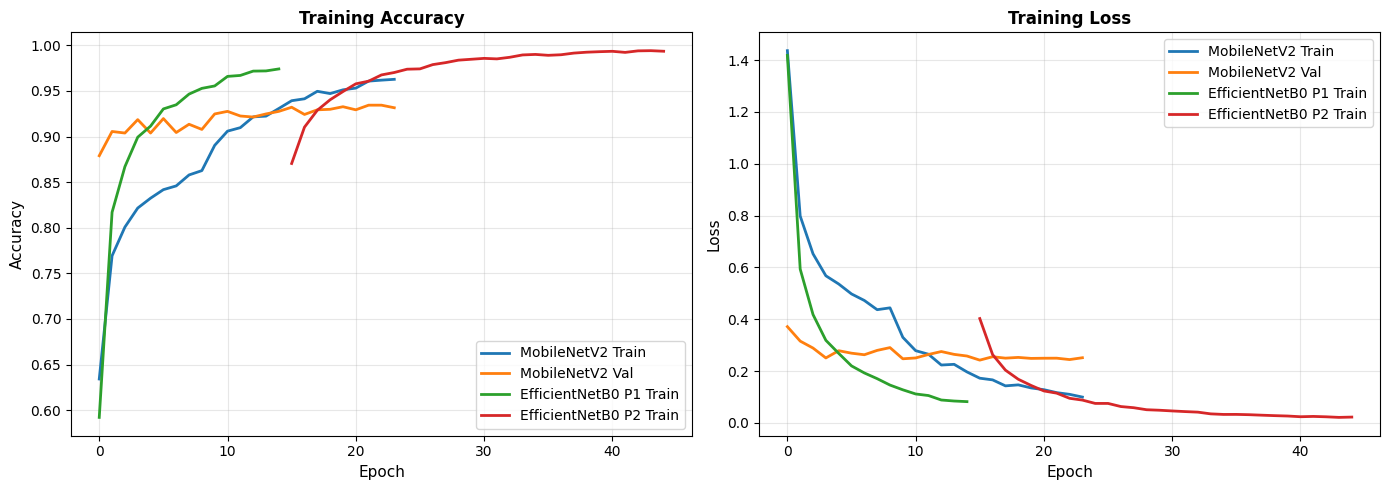

Training curves saved


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mobilenetv2_history.history['accuracy'], label='MobileNetV2 Train', linewidth=2)
axes[0].plot(mobilenetv2_history.history['val_accuracy'], label='MobileNetV2 Val', linewidth=2)
axes[0].plot(efficientnetb0_history_p1.history['accuracy'], label='EfficientNetB0 P1 Train', linewidth=2)
axes[0].plot([len(efficientnetb0_history_p1.history['accuracy']) + i for i in range(len(efficientnetb0_history_p2.history['accuracy']))],
             efficientnetb0_history_p2.history['accuracy'], label='EfficientNetB0 P2 Train', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Training Accuracy', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].plot(mobilenetv2_history.history['loss'], label='MobileNetV2 Train', linewidth=2)
axes[1].plot(mobilenetv2_history.history['val_loss'], label='MobileNetV2 Val', linewidth=2)
axes[1].plot(efficientnetb0_history_p1.history['loss'], label='EfficientNetB0 P1 Train', linewidth=2)
axes[1].plot([len(efficientnetb0_history_p1.history['loss']) + i for i in range(len(efficientnetb0_history_p2.history['loss']))],
             efficientnetb0_history_p2.history['loss'], label='EfficientNetB0 P2 Train', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves_morphological.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved")

In [44]:
results_df = pd.DataFrame([
    {'Model': 'MobileNetV2', 'Test_Accuracy': mobilenetv2_test_acc, 'Test_Loss': mobilenetv2_test_loss},
    {'Model': 'EfficientNetB0', 'Test_Accuracy': efficientnetb0_test_acc, 'Test_Loss': efficientnetb0_test_loss}
])

results_df.to_csv(OUTPUT_DIR / 'results_morphological.csv', index=False)
print(f"Results saved to {OUTPUT_DIR / 'results_morphological.csv'}")
print(results_df.to_string(index=False))

Results saved to /kaggle/working/results_morphological.csv
         Model  Test_Accuracy  Test_Loss
   MobileNetV2       0.923556   0.292734
EfficientNetB0       0.971121   0.099799
